<a href="https://colab.research.google.com/github/NikunjNPatel/Deep-Learning/blob/main/Practice-Notebooks/linear_regression_pt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [270]:
import torch
from torch import nn # nn contains all things needed for building neural networks
import matplotlib.pyplot as plt

In [271]:
# Generate synthetic data for linear regression
# Parameters
w0 = 0.5
w1 = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start,end+step,step).unsqueeze(dim=1) # Column vector
y = w0 + w1*X

print(X.shape)
print(y.shape)

torch.Size([51, 1])
torch.Size([51, 1])


In [272]:
from sklearn.model_selection import train_test_split

In [273]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [274]:
X_train.shape, y_train.shape

(torch.Size([40, 1]), torch.Size([40, 1]))

In [275]:
X_test.shape, y_test.shape

(torch.Size([11, 1]), torch.Size([11, 1]))

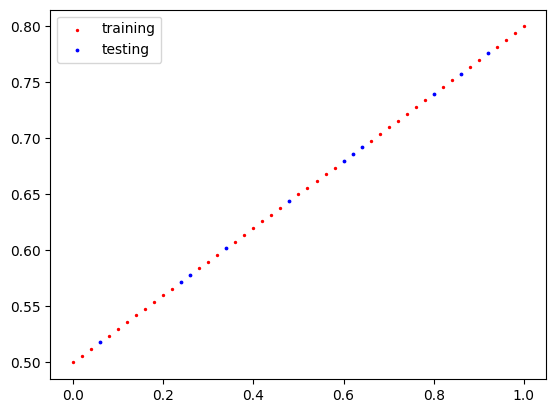

In [276]:
plt.scatter(X_train, y_train, c='r', s=2, label="training")
plt.scatter(X_test, y_test, c='b', s=3, label="testing")
plt.legend()

In [277]:
from numpy import require
class LinearRegressionModel(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.weights = nn.Parameter(data=torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(data=torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    # torch.Tensor always return float datatype value, while torch.tensor have dtype property to define or infer datatype from value
    return x * self.weights + self.bias



In [278]:
torch.manual_seed(42)
model = LinearRegressionModel()
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [279]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [280]:
y_pred = model(X_test)
y_pred

tensor([[0.4184],
        [0.3982],
        [0.4386],
        [0.2096],
        [0.2904],
        [0.3376],
        [0.2433],
        [0.3443],
        [0.1490],
        [0.3308],
        [0.2163]], grad_fn=<AddBackward0>)

In [281]:
# Make prediction using 'torch.inference_mode()'
# torch.inference_mode() make sure that operation within this doesn't interact with autograd
# torch.inference_mode() prefered over torch.no_grad()
with torch.inference_mode():
  y_pred = model(X_test)

y_pred

tensor([[0.4184],
        [0.3982],
        [0.4386],
        [0.2096],
        [0.2904],
        [0.3376],
        [0.2433],
        [0.3443],
        [0.1490],
        [0.3308],
        [0.2163]])

In [282]:
with torch.no_grad():
  y_pred = model(X_test)

y_pred

tensor([[0.4184],
        [0.3982],
        [0.4386],
        [0.2096],
        [0.2904],
        [0.3376],
        [0.2433],
        [0.3443],
        [0.1490],
        [0.3308],
        [0.2163]])

In [283]:
# loss function
loss_fn = nn.L1Loss()

# optimizer
opt = torch.optim.SGD(params=model.parameters(), lr=0.01)

Use them in the order - `opt.zero_grad()`, `loss.backward()`, `opt.step()`.

* `zero_grad` clears old gradients from the last step (otherwise you’d just accumulate the gradients from all loss.backward() calls).
* `loss.backward()` computes the derivative of the loss w.r.t. the parameters (or anything requiring gradients) using backpropagation.
* `opt.step()` causes the optimizer to take a step based on the gradients of the parameters.

- `model.eval()` will notify all your layers that you are in eval mode, that way, batchnorm or dropout layers will work in eval mode instead of training mode.
- `torch.no_grad()` impacts the autograd engine and deactivate it. It will reduce memory usage and speed up computations but you won’t be able to backprop (which you don’t want in an eval script).

In [284]:
# Training Loop
torch.manual_seed(42)
epochs = 100

epoch_count = []
training_loss = []
testing_loss = []

for epoch in range(epochs):
  model.train() # Train Mode

  y_pred = model(X_train) # Forward pass
  loss = loss_fn(y_pred, y_train) # Loss function
  opt.zero_grad() # Set all gradient of parameters to zero
  loss.backward() # Calculate gradient of parameter with respect to loss, i.e. backpropagation
  opt.step() # Update the parameters with respect to calculated gradient above

  model.eval() # Testing or Evaluation Mode
  with torch.inference_mode():
    test_pred = model(X_test)
    test_loss = loss_fn(test_pred, y_test)

  epoch_count.append(epoch)
  training_loss.append(loss)
  testing_loss.append(test_loss)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Training Loss: {loss} | Testing Loss: {test_loss}")


Epoch: 0 | Training Loss: 0.35313889384269714 | Testing Loss: 0.33917492628097534
Epoch: 10 | Training Loss: 0.2289324700832367 | Testing Loss: 0.21314357221126556
Epoch: 20 | Training Loss: 0.10472607612609863 | Testing Loss: 0.08711232244968414
Epoch: 30 | Training Loss: 0.04547639563679695 | Testing Loss: 0.03622976318001747
Epoch: 40 | Training Loss: 0.03804401680827141 | Testing Loss: 0.03220271319150925
Epoch: 50 | Training Loss: 0.032573066651821136 | Testing Loss: 0.02787279523909092
Epoch: 60 | Training Loss: 0.0271785669028759 | Testing Loss: 0.023181192576885223
Epoch: 70 | Training Loss: 0.021781984716653824 | Testing Loss: 0.01848960481584072
Epoch: 80 | Training Loss: 0.016385404393076897 | Testing Loss: 0.013798014260828495
Epoch: 90 | Training Loss: 0.010988825000822544 | Testing Loss: 0.009106416255235672


In [285]:
# Actual parameters
bias = w0
weights = w1
print(f"Bias: {bias}, Weights: {weights}")

Bias: 0.5, Weights: 0.3


In [286]:
model.state_dict()

OrderedDict([('weights', tensor([0.3213])), ('bias', tensor([0.4888]))])

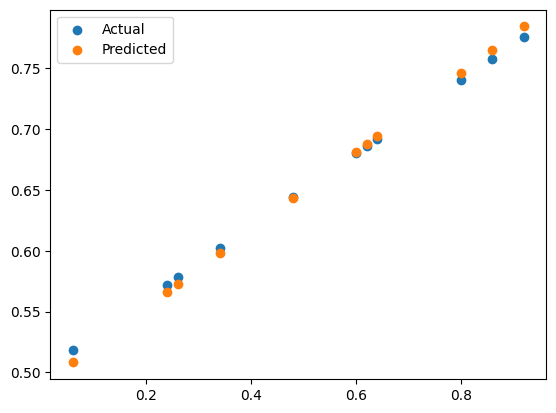

In [287]:
with torch.inference_mode():
  y_pred = model(X_test)

plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.legend()

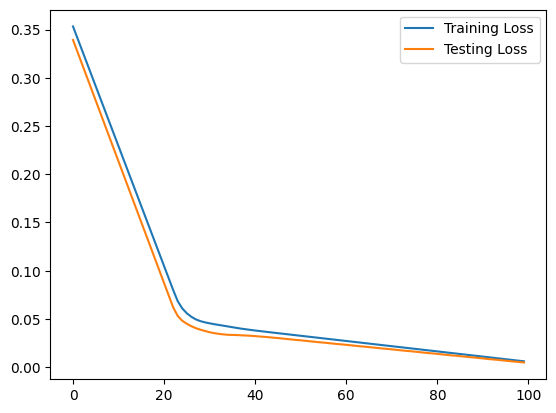

In [288]:
plt.plot(epoch_count, torch.tensor(training_loss).numpy(), label="Training Loss")
plt.plot(epoch_count, torch.tensor(testing_loss).numpy(), label="Testing Loss")
plt.legend()

Saving model in pytorch

- `torch.save()` to save model as pickle file
- `torch.load()` to load model
- `torch.nn.Module.load_state_dict()` to load a model saved state dictionary

In [294]:
torch.save(model.state_dict(),'linear_regression.pth')

In [300]:
saved_model = LinearRegressionModel()
saved_model.load_state_dict(torch.load('linear_regression.pth'))

<All keys matched successfully>

In [302]:
saved_model.eval()
with torch.inference_mode():
  y_pred_saved = saved_model(X_test)
y_pred_saved

tensor([[0.7651],
        [0.7458],
        [0.7844],
        [0.5659],
        [0.6430],
        [0.6880],
        [0.5981],
        [0.6944],
        [0.5081],
        [0.6816],
        [0.5723]])

In [303]:
y_pred == y_pred_saved

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])